Introduction :

The Video Game Sales: dataset provides detailed information about video game releases, including their genres, platforms, publishers, and sales performance across different regions of the world. This dataset is widely used for data analysis and visualization because it covers several decades of gaming industry history and allows us to explore trends, patterns, and factors that may influence game sales globally.

In this notebook, I will perform a full exploratory data analysis (EDA) to understand the structure of the dataset and extract meaningful insights. The analysis will include the following steps:

 Loading and Inspecting the Dataset

I will begin by importing the dataset into a pandas DataFrame and displaying its structure, features, and basic statistics. This helps in understanding the type of data we are working with.

 Data Cleaning

The dataset contains missing values, especially in the Year and Publisher columns. To ensure accurate analysis, I will clean the data by either removing missing values or filling them using appropriate techniques.

 Data Visualization**

To better understand the gaming industry trends, I will create several visualizations, including:

 Number of games released per year
 Distribution of game genres
 Sales trends across regions
 Top-selling platforms and publishers
 Relationships between global sales and other variables

These visualizations will help highlight key patterns and insights.

 Insights and Interpretation

At each step, I will describe the findings and interpret what the visualizations reveal about the gaming industry, sales patterns, and consumer preferences.







In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use("ggplot")

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/xpohtetu-jpg/summerspringboardproject/main/vgsales.csv")
df

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [4]:
df.head(15)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [5]:
df.tail()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.0,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01


In [6]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [7]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [8]:
df.rename(columns={
    "Global_Sales": "GlobalSales",
    "NA_Sales": "NASales",
    "EU_Sales": "EUSales",
    "JP_Sales": "JPSales",
    "Other_Sales": "OtherSales"
}, inplace=True)

filling with using mode

In [9]:
df['Genre'] = df['Genre'].fillna(df['Genre'].mode()[0])
df['Publisher'] = df['Publisher'].fillna(df['Publisher'].mode()[0])


Data Visuaization

1. Distribution of Global Sales

Explanation (put under the plot):
This visualization shows the distribution of global video game sales. The histogram helps identify how most games perform in the market. We can observe that a large number of games have relatively low global sales, while only a few titles achieve extremely high sales.

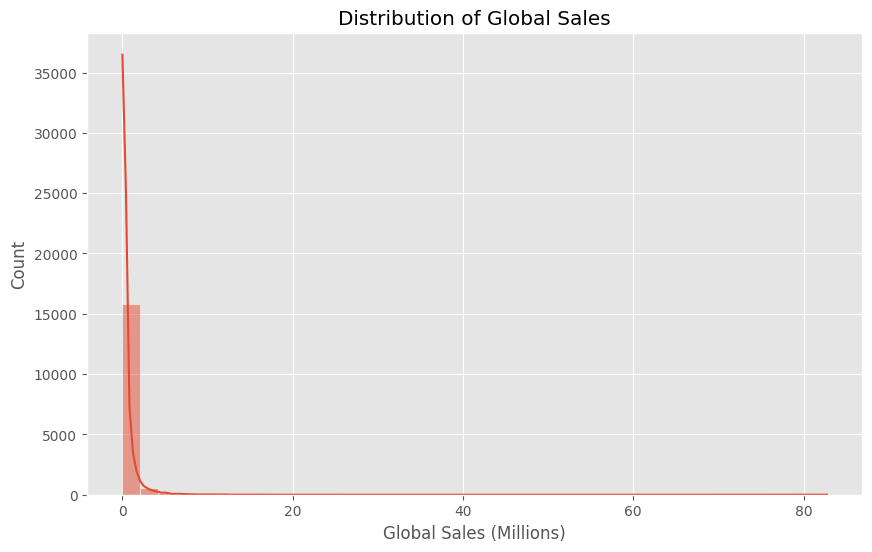

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(df['GlobalSales'], bins=40, kde=True)
plt.title("Distribution of Global Sales")
plt.xlabel("Global Sales (Millions)")
plt.ylabel("Count")
plt.show()


2. Top 10 Best-Selling Games

Explanation:
This bar chart displays the top 10 best-selling games based on global sales. It highlights the most successful video games in history and shows how their sales dominate the market compared to other titles.

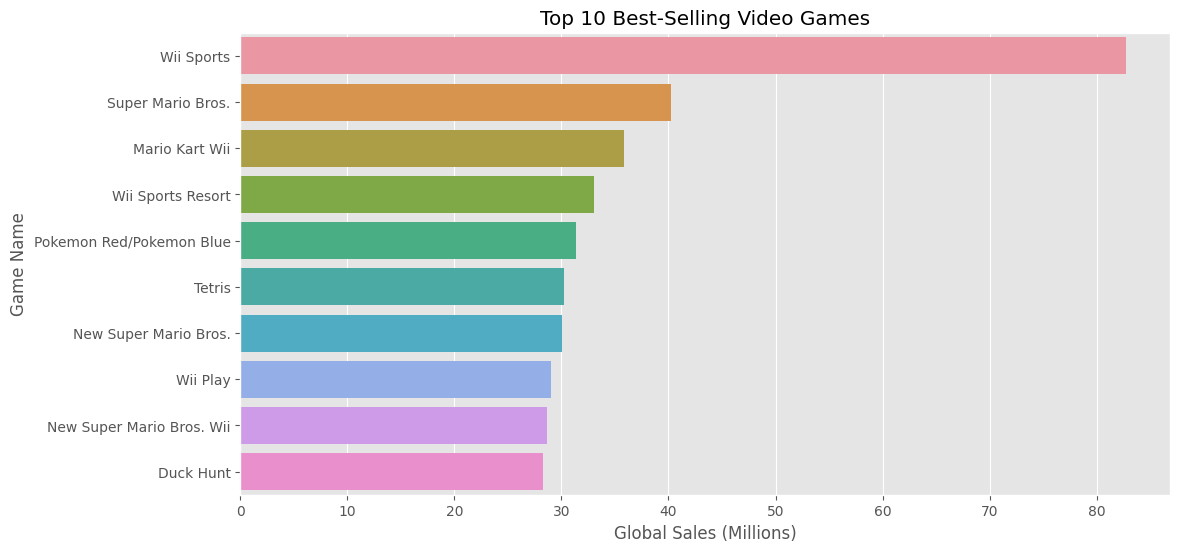

In [11]:
top_games = df.sort_values(by="GlobalSales", ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(data=top_games, x="GlobalSales", y="Name")
plt.title("Top 10 Best-Selling Video Games")
plt.xlabel("Global Sales (Millions)")
plt.ylabel("Game Name")
plt.show()


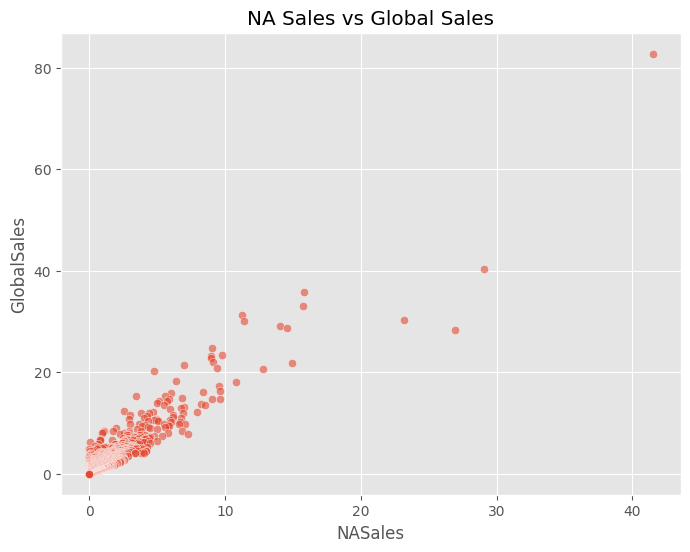

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="NASales", y="GlobalSales", alpha=0.6)
plt.title("NA Sales vs Global Sales")
plt.show()


In [13]:
earliest_year = df['Year'].dropna().min()
latest_year = df['Year'].dropna().max()
unique_years = df['Year'].dropna().nunique()
most_releases_year = df['Year'].dropna().mode()[0]

print("Earliest Year:", earliest_year)
print("Latest Year:", latest_year)
print("Unique Years:", unique_years)
print("Most Releases Year:", most_releases_year)


Earliest Year: 1980.0
Latest Year: 2020.0
Unique Years: 39
Most Releases Year: 2009.0


3. Number of Games Released per Year

Explanation:
This count plot shows how many video games were released each year. It reveals trends in the gaming industry, such as periods of growth, peak production years, and declines in game releases over time

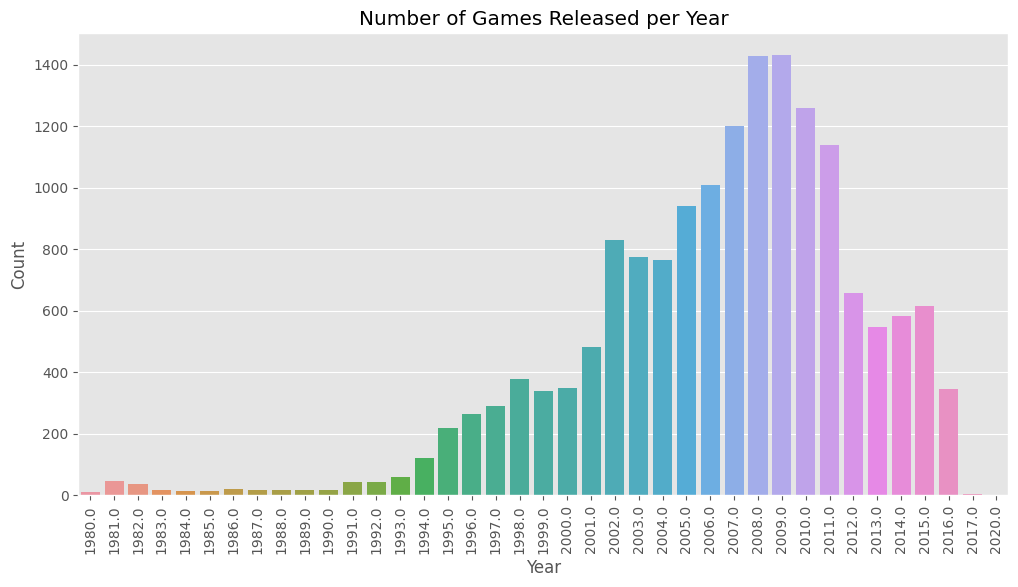

In [14]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="Year")
plt.xticks(rotation=90)
plt.title("Number of Games Released per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


4. Total Global Sales per Platform

Explanation:
This chart presents the total global sales for each gaming platform. It helps identify which platforms were historically the most successful in terms of revenue generation and market influence

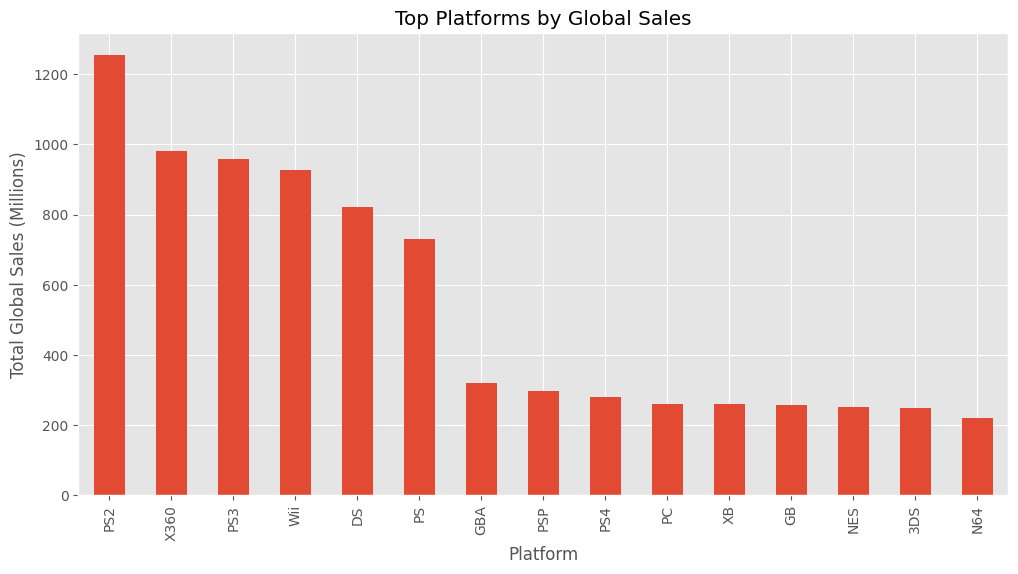

In [15]:
platform_sales = df.groupby("Platform")["GlobalSales"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
platform_sales.head(15).plot(kind="bar")
plt.title("Top Platforms by Global Sales")
plt.xlabel("Platform")
plt.ylabel("Total Global Sales (Millions)")
plt.show()


5. Total Sales per Publisher

Explanation:
This bar plot shows the top publishers ranked by their total global sales. It highlights which companies have contributed the most to the video game industry through high-selling titles.

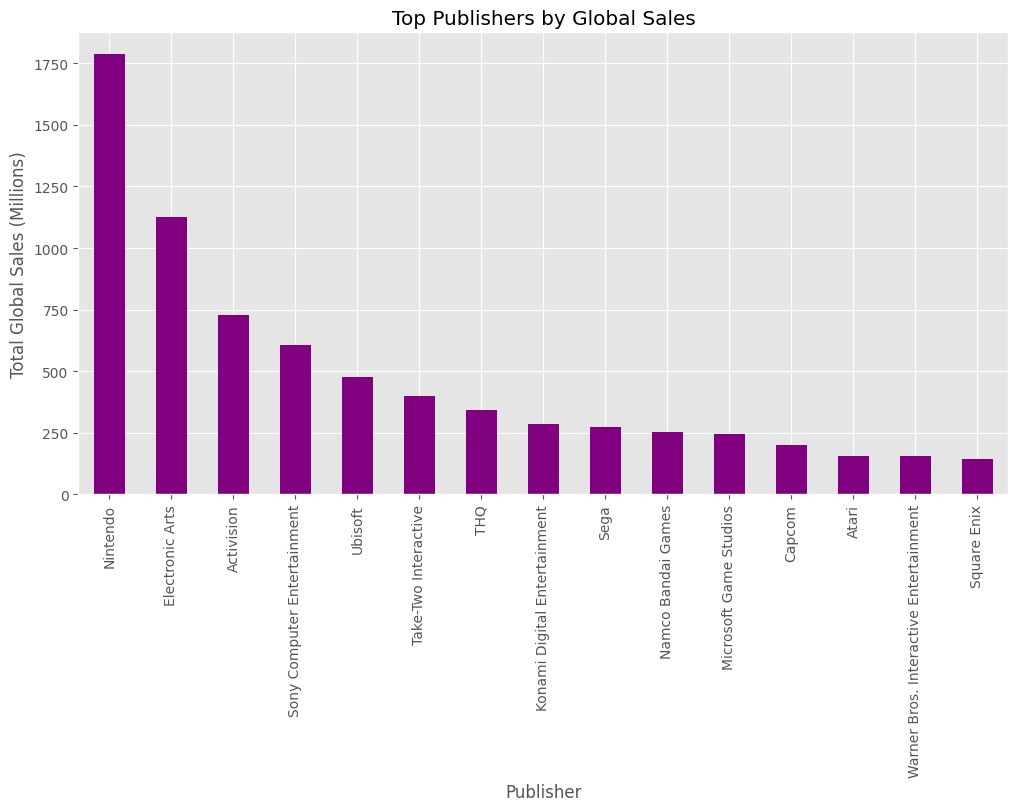

In [16]:
publisher_sales = df.groupby("Publisher")["GlobalSales"].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,6))
publisher_sales.plot(kind="bar", color="purple")
plt.title("Top Publishers by Global Sales")
plt.xlabel("Publisher")
plt.ylabel("Total Global Sales (Millions)")
plt.show()


6. Global Sales by Genre

Explanation:
This bar chart compares global sales across different game genres. It provides insight into which genres appeal most to players worldwide and which ones generate the highest revenue.

In [17]:
genre_sales = df.groupby("Genre")["GlobalSales"].sum().sort_values(ascending=False)

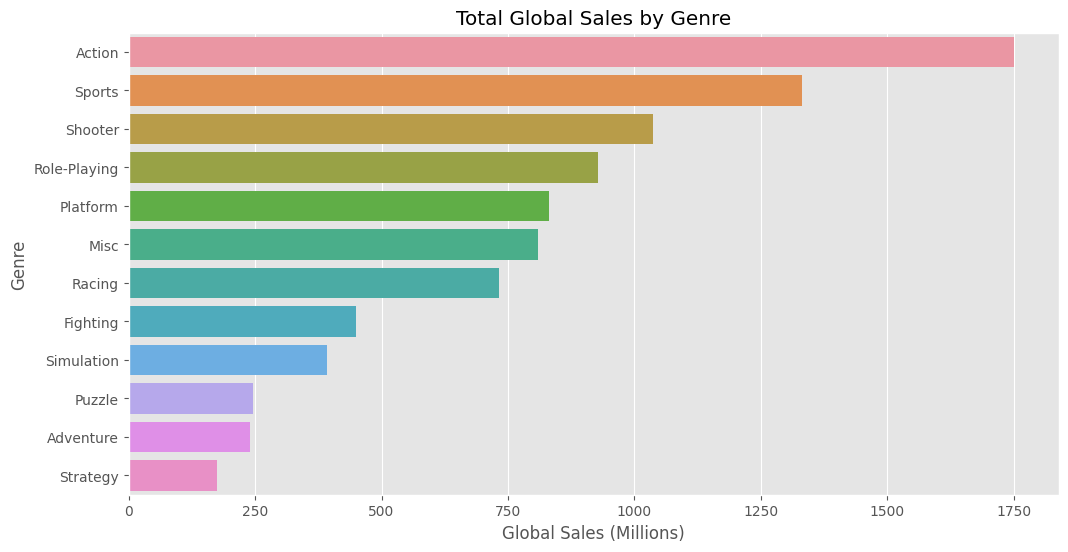

In [18]:

plt.figure(figsize=(12,6))
sns.barplot(x=genre_sales.values, y=genre_sales.index)
plt.title("Total Global Sales by Genre")
plt.xlabel("Global Sales (Millions)")
plt.ylabel("Genre")
plt.show()


7. Regional Sales Distribution (Pie Chart)

Explanation:
This pie chart visualizes the share of total video game sales across different global regions. It shows how the market is divided between North America, Europe, Japan, and the rest of the world

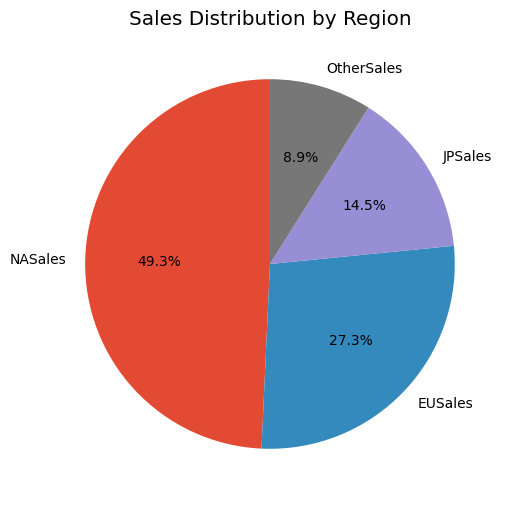

In [19]:
region_sales = df[['NASales','EUSales','JPSales','OtherSales']].sum()

plt.figure(figsize=(8,6))
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', startangle=90)
plt.title("Sales Distribution by Region")
plt.show()


8. Correlation Heatmap

Explanation:
The heatmap displays the correlation between sales in different regions and global sales. Stronger correlations indicate regions that contribute the most to overall global revenue

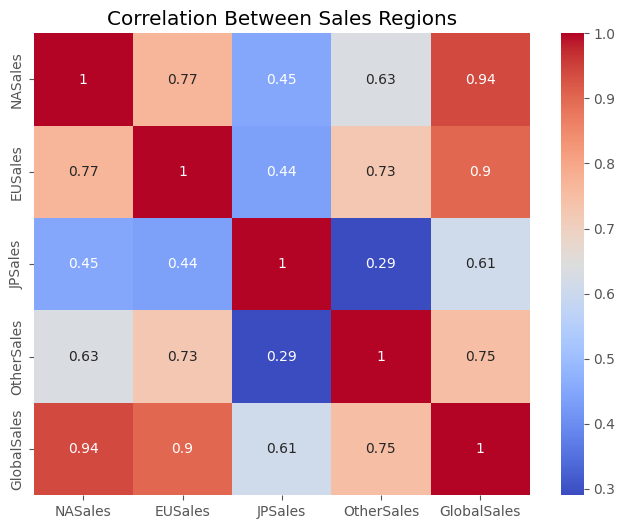

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['NASales','EUSales','JPSales','OtherSales','GlobalSales']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Between Sales Regions")
plt.show()


Pairplot for analyzing relationships between sales regions

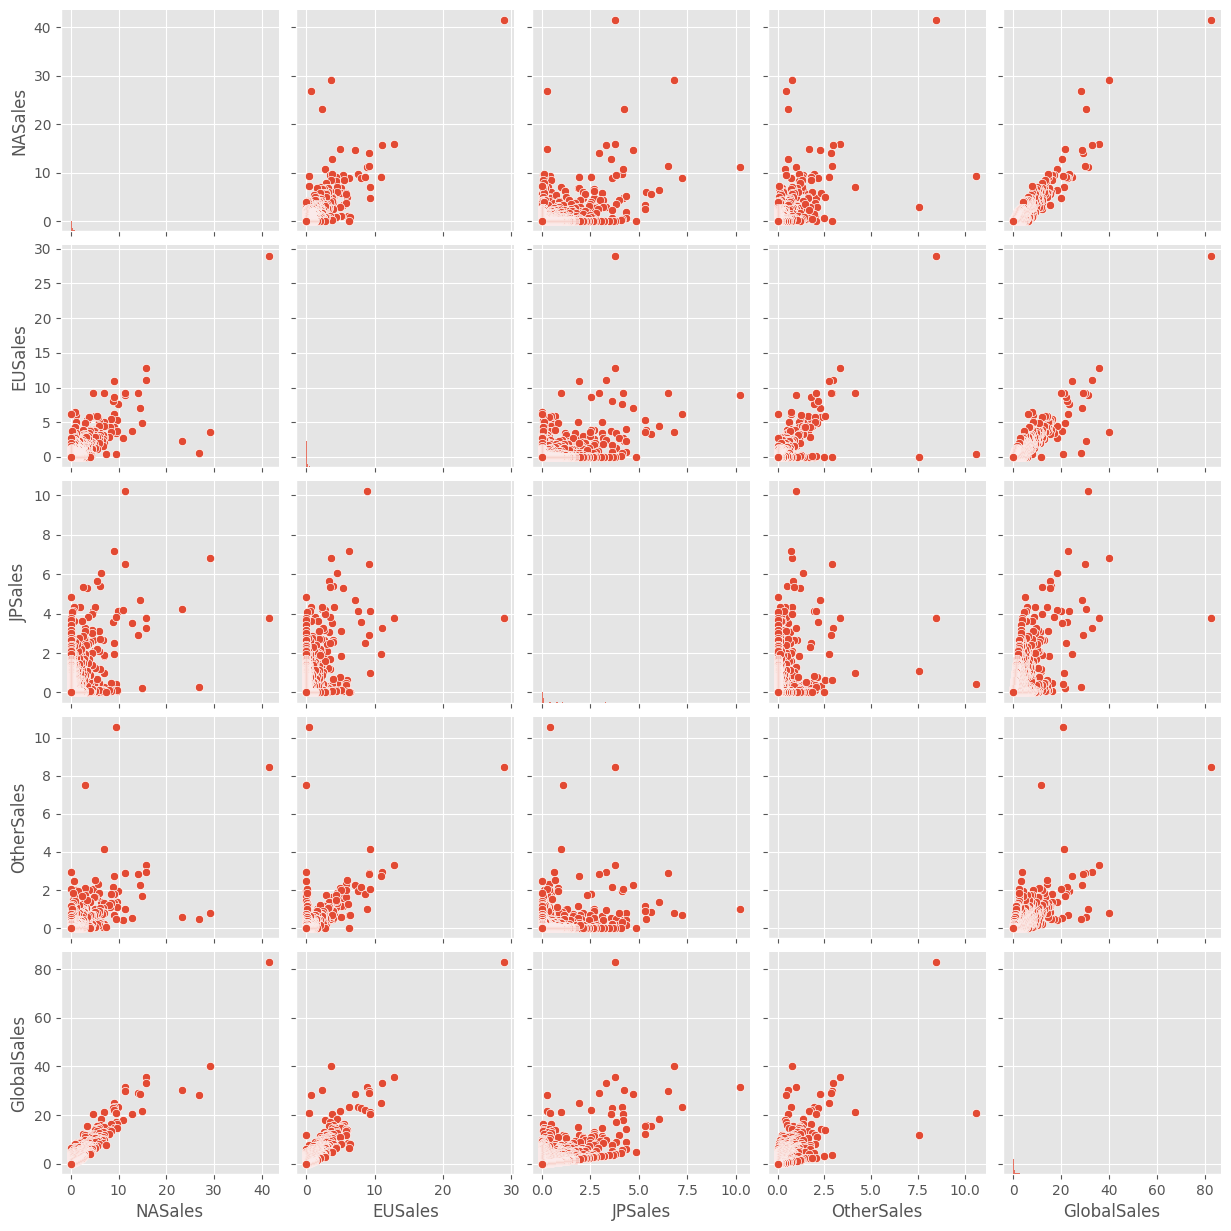

In [21]:
sns.pairplot(df[['NASales', 'EUSales', 'JPSales', 'OtherSales', 'GlobalSales']])
plt.show()


Barplot for the number of games per year

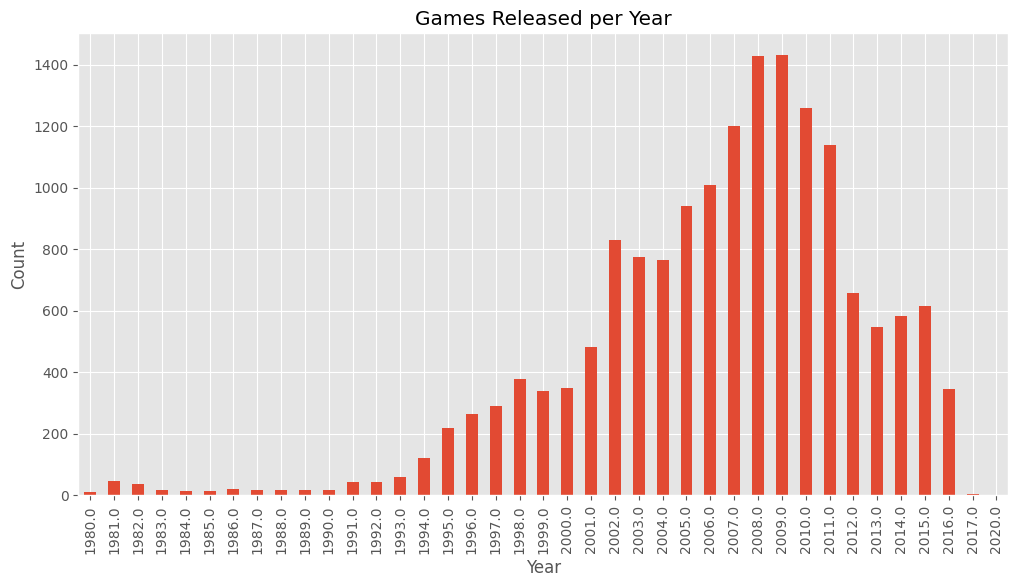

In [22]:
games_per_year = df['Year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
games_per_year.plot(kind="bar")
plt.title("Games Released per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


Stacked Bar – Compare Sales by Genre

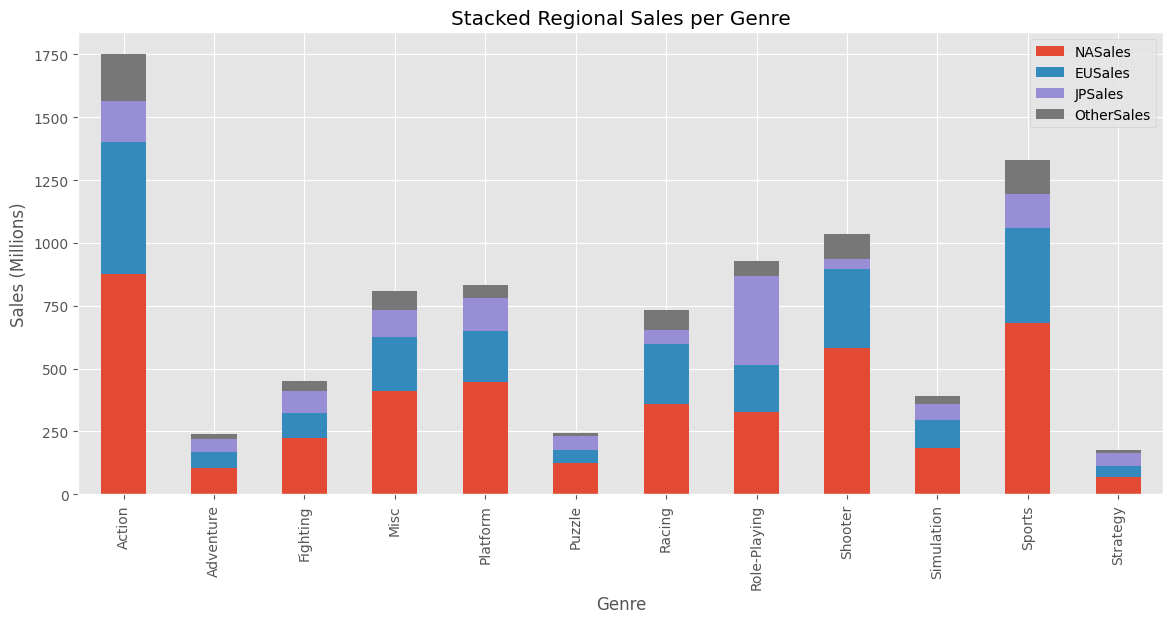

In [23]:
genre_regions = df.groupby("Genre")[['NASales','EUSales','JPSales','OtherSales']].sum()

genre_regions.plot(kind='bar', stacked=True, figsize=(14,6))
plt.title("Stacked Regional Sales per Genre")
plt.ylabel("Sales (Millions)")
plt.show()
